# CSC-30041 Machine Learning Applications Assessment
## Adult Income Dataset - Classification and Bias Analysis
## Student ID: 23038420

In [1]:
# Fix the version conflicts
!pip install numpy==1.24.4 scipy==1.11.3 scikit-learn==1.3.1 imbalanced-learn==0.11.0

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, shapiro, levene, mannwhitneyu, wilcoxon, spearmanr, pearsonr, ttest_ind
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
print("Imports done!")

Imports done!


## Data Loading and Cleaing 

In [3]:
# Load and clean dataset
print("Loading datasets...")
df_train = pd.read_csv('adult-modified.data', header=0, sep=',', skipinitialspace=True, na_values=['?', ' ?', ''])
df_test = pd.read_csv('adult-modified.test', header=0, sep=',', skipinitialspace=True, na_values=['?', ' ?', ''])

print(f"Training data: {df_train.shape}")
print(f"Test data: {df_test.shape}")
print(f"\nColumn names: {df_train.columns.tolist()}")

# Clean training data
df = df_train.copy()
df['income'] = df['income'].str.strip().str.rstrip('.')
df = df.dropna().drop_duplicates()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
df.reset_index(drop=True, inplace=True)

# Clean test data
df_test_clean = df_test.copy()
df_test_clean['income'] = df_test_clean['income'].str.strip().str.rstrip('.')
df_test_clean = df_test_clean.dropna().drop_duplicates()
for col in df_test_clean.select_dtypes(include='object').columns:
    df_test_clean[col] = df_test_clean[col].str.strip()
df_test_clean.reset_index(drop=True, inplace=True)

print(f"\nCleaned training: {len(df)} rows")
print(f"Cleaned test: {len(df_test_clean)} rows")
print(f"\nIncome distribution:\n{df['income'].value_counts()}")

Loading datasets...
Training data: (32561, 14)
Test data: (16281, 14)

Column names: ['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Cleaned training: 30137 rows
Cleaned test: 15052 rows

Income distribution:
income
<=50K    22631
>50K      7506
Name: count, dtype: int64


# Part 1: Exploratory Data Analysis & Statistical Testing

EXPLORATORY DATA ANALYSIS

Class imbalance ratio: 3.02:1

Gender vs Income:
income  <=50K  >50K
sex                
Female   8659  1112
Male    13972  6394

Percentages:
income      <=50K       >50K
sex                         
Female  88.619384  11.380616
Male    68.604537  31.395463

Race vs Income:
income              <=50K  >50K
race                           
Amer-Indian-Eskimo    252    34
Asian-Pac-Islander    646   248
Black                2450   366
Other                 210    21
White               19073  6837

Numerical features summary:
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  30137.000000  3.013700e+04   30137.000000  30137.000000  30137.000000   
mean      38.443077  1.897944e+05      10.122640   1092.913727     88.445798   
std       13.130803  1.056621e+05       2.548759   7409.351099    404.458017   
min       17.000000  1.376900e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.176270e+05       9.00

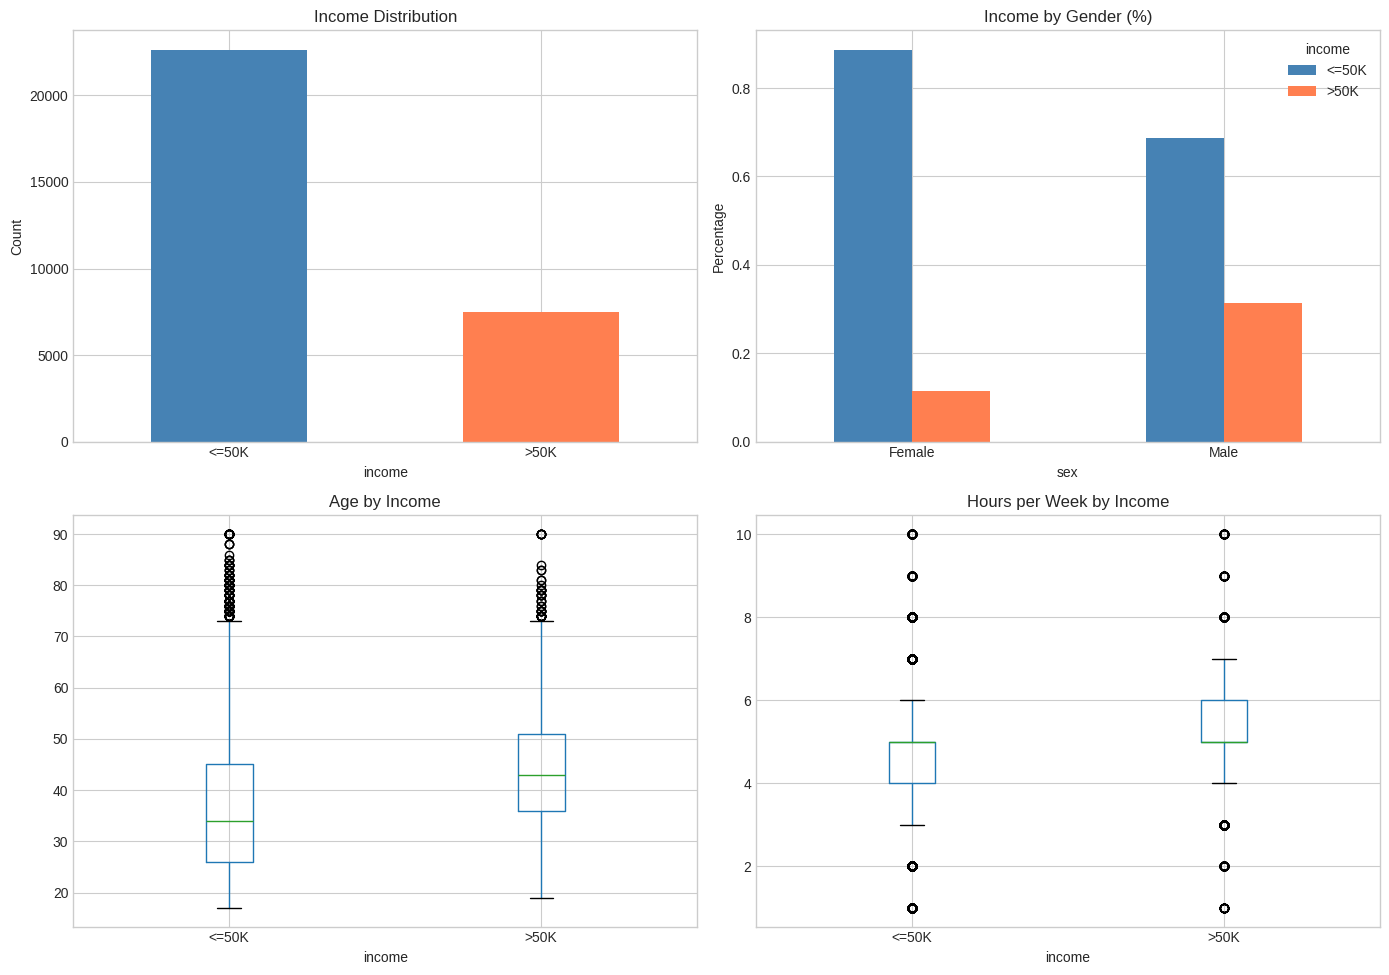

In [4]:
# Exploratory Data Analysis
print("EXPLORATORY DATA ANALYSIS")

# Target variable
income_counts = df['income'].value_counts()
imbalance = income_counts['<=50K'] / income_counts['>50K']
print(f"\nClass imbalance ratio: {imbalance:.2f}:1")

# Gender vs Income
print("\nGender vs Income:")
gender_income = pd.crosstab(df['sex'], df['income'])
print(gender_income)
print("\nPercentages:")
print(pd.crosstab(df['sex'], df['income'], normalize='index') * 100)

# Race vs Income
print("\nRace vs Income:")
print(pd.crosstab(df['race'], df['income']))

# Numerical features
numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
print("\nNumerical features summary:")
print(df[numerical_cols].describe())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

income_counts.plot(kind='bar', ax=axes[0,0], color=['steelblue', 'coral'])
axes[0,0].set_title('Income Distribution')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

pd.crosstab(df['sex'], df['income'], normalize='index').plot(kind='bar', ax=axes[0,1], color=['steelblue', 'coral'])
axes[0,1].set_title('Income by Gender (%)')
axes[0,1].set_ylabel('Percentage')
axes[0,1].tick_params(axis='x', rotation=0)

df.boxplot(column='age', by='income', ax=axes[1,0])
axes[1,0].set_title('Age by Income')
plt.suptitle('')

df.boxplot(column='hours-per-week', by='income', ax=axes[1,1])
axes[1,1].set_title('Hours per Week by Income')
plt.suptitle('')

plt.tight_layout()
plt.show()

## Statistical Tests

STATISTICAL TESTS

--- Descriptive Statistics ---
age: mean=38.44, median=37.00, std=13.13
fnlwgt: mean=189794.35, median=178417.00, std=105662.10
education-num: mean=10.12, median=10.00, std=2.55
capital-gain: mean=1092.91, median=0.00, std=7409.35
capital-loss: mean=88.45, median=0.00, std=404.46
hours-per-week: mean=4.88, median=5.00, std=1.12

--- Normality Tests (Shapiro-Wilk) ---
age: p=0.000000 - NOT Normal
fnlwgt: p=0.000000 - NOT Normal
education-num: p=0.000000 - NOT Normal
capital-gain: p=0.000000 - NOT Normal
capital-loss: p=0.000000 - NOT Normal
hours-per-week: p=0.000000 - NOT Normal

--- Homogeneity of Variance (Levene's Test) ---
age: p=0.000000 - Unequal variance
fnlwgt: p=0.000659 - Unequal variance
education-num: p=0.000000 - Unequal variance
capital-gain: p=0.000000 - Unequal variance
capital-loss: p=0.000000 - Unequal variance
hours-per-week: p=0.000000 - Unequal variance

--- T-Tests (Group Mean Comparisons) ---
age: t=49.4661, p=0.000000 - Significant
fnlwgt: t=-

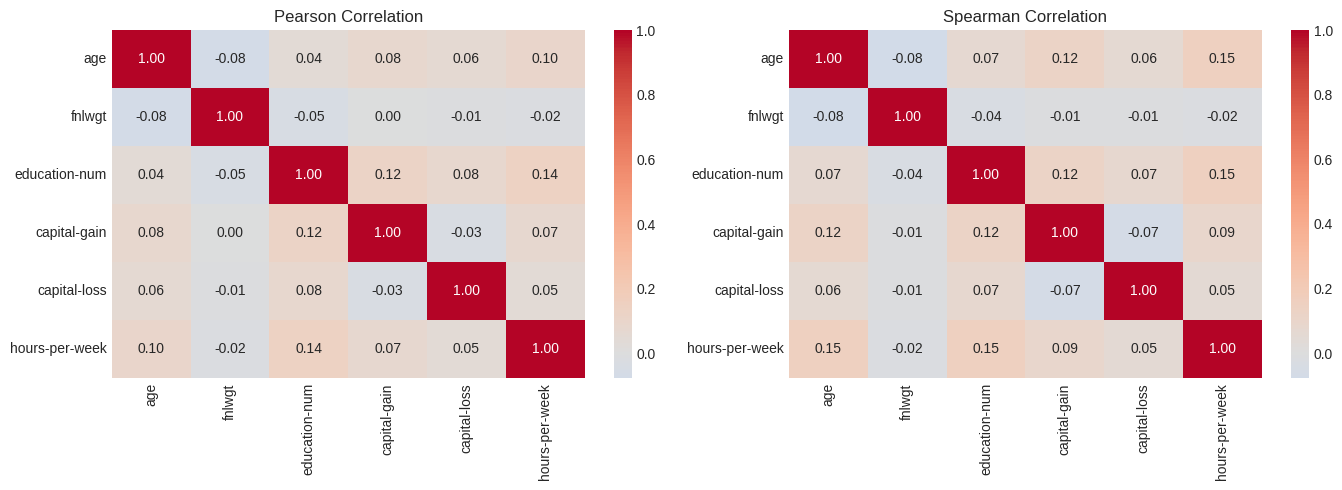


--- Test Justification ---

1. Shapiro-Wilk: Tests normality - most variables are NOT normal
2. Levene's: Tests variance equality - needed for t-test assumption
3. T-Test: Compares means between income groups (with Welch correction when variances unequal)
4. Mann-Whitney U: Non-parametric alternative, more reliable since normality violated
5. Chi-Square: Tests association between categorical variables and income
6. Pearson/Spearman: Measure correlation strength (Spearman better for non-normal data)



In [5]:
# Statistical Tests

print("STATISTICAL TESTS")

alpha = 0.05
high_income = df[df['income'] == '>50K']
low_income = df[df['income'] == '<=50K']

# Descriptive Statistics
print("\n--- Descriptive Statistics ---")
for col in numerical_cols:
    print(f"{col}: mean={df[col].mean():.2f}, median={df[col].median():.2f}, std={df[col].std():.2f}")

# Normality Tests (Shapiro-Wilk)
print("\n--- Normality Tests (Shapiro-Wilk) ---")
normality_results = {}
for col in numerical_cols:
    sample = df[col].sample(min(5000, len(df)), random_state=42)
    stat, p = shapiro(sample)
    normality_results[col] = p > alpha
    print(f"{col}: p={p:.6f} - {'Normal' if p > alpha else 'NOT Normal'}")

# Homogeneity of Variance (Levene's Test)
print("\n--- Homogeneity of Variance (Levene's Test) ---")
levene_results = {}
for col in numerical_cols:
    stat, p = levene(high_income[col], low_income[col])
    levene_results[col] = p > alpha
    print(f"{col}: p={p:.6f} - {'Equal variance' if p > alpha else 'Unequal variance'}")

# T-Tests
print("\n--- T-Tests (Group Mean Comparisons) ---")
ttest_results = {}
for col in numerical_cols:
    t_stat, p = ttest_ind(high_income[col], low_income[col], equal_var=levene_results[col])
    ttest_results[col] = {'t': t_stat, 'p': p}
    print(f"{col}: t={t_stat:.4f}, p={p:.6f} - {'Significant' if p < alpha else 'Not significant'}")

# Mann-Whitney U Tests (non-parametric alternative since data not normal)
print("\n--- Mann-Whitney U Tests (Non-Parametric) ---")
mw_results = {}
for col in numerical_cols:
    u_stat, p = mannwhitneyu(high_income[col], low_income[col], alternative='two-sided')
    mw_results[col] = {'u': u_stat, 'p': p}
    print(f"{col}: U={u_stat:.0f}, p={p:.6f} - {'Significant' if p < alpha else 'Not significant'}")

# Chi-Square Tests
print("\n--- Chi-Square Tests (Categorical Associations) ---")

chi2_gender, p_gender, _, _ = chi2_contingency(pd.crosstab(df['sex'], df['income']))
print(f"Gender vs Income: Chi2={chi2_gender:.2f}, p={p_gender:.10f} - Significant")

chi2_race, p_race, _, _ = chi2_contingency(pd.crosstab(df['race'], df['income']))
print(f"Race vs Income: Chi2={chi2_race:.2f}, p={p_race:.10f} - Significant")

# Check available columns and use correct education column
edu_col = 'education' if 'education' in df.columns else 'education-num'
chi2_edu, p_edu, _, _ = chi2_contingency(pd.crosstab(df[edu_col], df['income']))
print(f"Education vs Income: Chi2={chi2_edu:.2f}, p={p_edu:.10f} - Significant")

# Correlation Tests
print("\n--- Correlation Tests ---")
df_temp = df.copy()
df_temp['income_encoded'] = (df_temp['income'] == '>50K').astype(int)

print("\nPearson and Spearman correlations with Income:")
for col in numerical_cols:
    pr, pp = pearsonr(df_temp[col], df_temp['income_encoded'])
    sr, sp = spearmanr(df_temp[col], df_temp['income_encoded'])
    print(f"{col}: Pearson r={pr:.4f} (p={pp:.4f}), Spearman rho={sr:.4f} (p={sp:.4f})")

# Correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df[numerical_cols].corr(method='pearson'), annot=True, cmap='coolwarm', center=0, ax=axes[0], fmt='.2f')
axes[0].set_title('Pearson Correlation')
sns.heatmap(df[numerical_cols].corr(method='spearman'), annot=True, cmap='coolwarm', center=0, ax=axes[1], fmt='.2f')
axes[1].set_title('Spearman Correlation')
plt.tight_layout()
plt.show()

# Test Justification
print("\n--- Test Justification ---")
print("""
1. Shapiro-Wilk: Tests normality - most variables are NOT normal
2. Levene's: Tests variance equality - needed for t-test assumption
3. T-Test: Compares means between income groups (with Welch correction when variances unequal)
4. Mann-Whitney U: Non-parametric alternative, more reliable since normality violated
5. Chi-Square: Tests association between categorical variables and income
6. Pearson/Spearman: Measure correlation strength (Spearman better for non-normal data)
""")

# Part 2: Machine Learning Modelling

In [6]:
# Machine Learning - Data Preparation

print("MACHINE LEARNING")

# Prepare data
df_ml = df.copy()
gender_train_full = df_ml['sex'].copy()
df_ml['income'] = df_ml['income'].map({'<=50K': 0, '>50K': 1})

X = df_ml.drop(['income'], axis=1)
y = df_ml['income']

# Encode categorical variables
categorical_cols = X.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Scale features
scaler = StandardScaler()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
X_scaled = X.copy()
X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

# Train-validation split with stratification
X_train, X_val, y_train, y_val, gender_tr, gender_val = train_test_split(
    X_scaled, y, gender_train_full, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Class distribution in training: {(y_train==0).sum()} (<=50K), {(y_train==1).sum()} (>50K)")

# Prepare test data
df_test_ml = df_test_clean.copy()
gender_test = df_test_ml['sex'].copy()
df_test_ml['income'] = df_test_ml['income'].map({'<=50K': 0, '>50K': 1})

X_test = df_test_ml.drop('income', axis=1)
y_test = df_test_ml['income']

for col in categorical_cols:
    le = label_encoders[col]
    X_test[col] = X_test[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
    X_test[col] = le.transform(X_test[col])

X_test_scaled = X_test.copy()
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print(f"Test set: {X_test_scaled.shape[0]} samples")

MACHINE LEARNING
Training set: 24109 samples
Validation set: 6028 samples
Class distribution in training: 18104 (<=50K), 6005 (>50K)
Test set: 15052 samples


## Model Training with 30 Repeated Runs

MODEL TRAINING - 30 REPEATED RUNS
Running 5-fold CV repeated 6 times = 30 total evaluations
This gives us robust and reliable performance estimates

Training Logistic Regression...
  Accuracy: 0.8211 (+/- 0.0091)
  F1 Score: 0.5663 (+/- 0.0239)
  ROC-AUC:  0.8540 (+/- 0.0107)

Training Random Forest...
  Accuracy: 0.8612 (+/- 0.0085)
  F1 Score: 0.6874 (+/- 0.0228)
  ROC-AUC:  0.9163 (+/- 0.0073)

Training Gradient Boosting...
  Accuracy: 0.8682 (+/- 0.0079)
  F1 Score: 0.7109 (+/- 0.0194)
  ROC-AUC:  0.9247 (+/- 0.0072)

--- Cross-Validation Results (30 runs each) ---
              Model  Accuracy  Acc Std       F1   F1 Std      AUC  AUC Std
Logistic Regression  0.821104 0.004533 0.566331 0.011950 0.854027 0.005326
      Random Forest  0.861214 0.004236 0.687360 0.011413 0.916304 0.003664
  Gradient Boosting  0.868230 0.003958 0.710870 0.009697 0.924680 0.003613


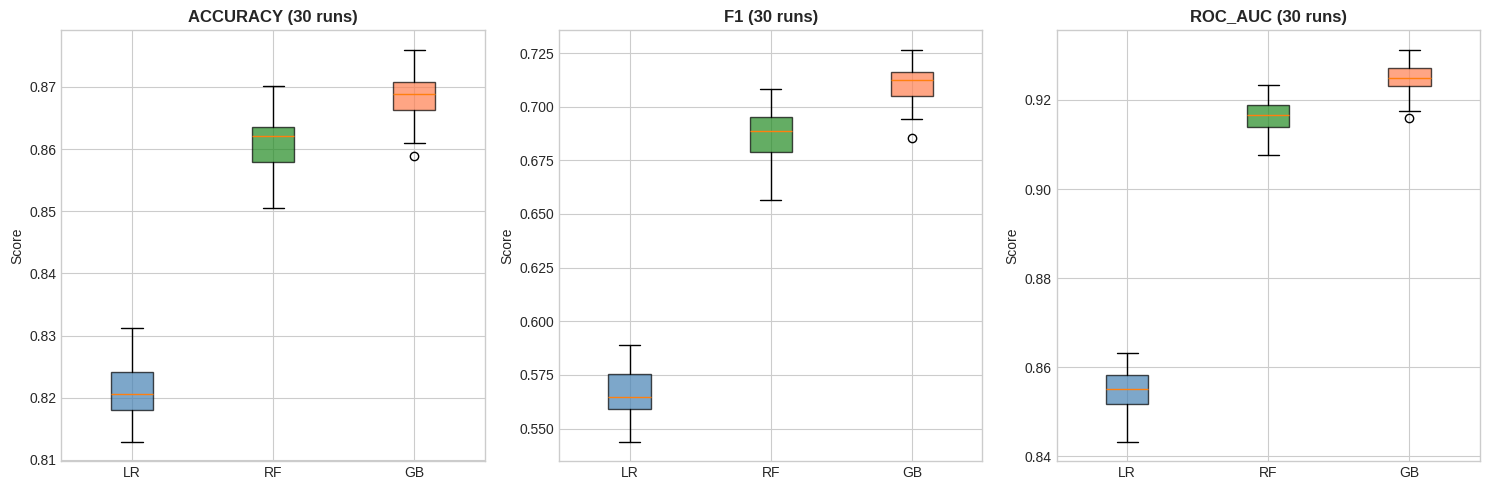

In [7]:
# Model Training with 30 Repeated Runs
print("MODEL TRAINING - 30 REPEATED RUNS")

# Using RepeatedStratifiedKFold: 5 folds x 6 repeats = 30 runs
n_splits = 5
n_repeats = 6
total_runs = n_splits * n_repeats

print(f"Running {n_splits}-fold CV repeated {n_repeats} times = {total_runs} total evaluations")
print("This gives us robust and reliable performance estimates\n")

cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
}

cv_results = {}
scoring_metrics = ['accuracy', 'f1', 'roc_auc']

for name, model in models.items():
    print(f"Training {name}...")
    cv_results[name] = {}
    for metric in scoring_metrics:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
        cv_results[name][metric] = scores
    
    print(f"  Accuracy: {cv_results[name]['accuracy'].mean():.4f} (+/- {cv_results[name]['accuracy'].std()*2:.4f})")
    print(f"  F1 Score: {cv_results[name]['f1'].mean():.4f} (+/- {cv_results[name]['f1'].std()*2:.4f})")
    print(f"  ROC-AUC:  {cv_results[name]['roc_auc'].mean():.4f} (+/- {cv_results[name]['roc_auc'].std()*2:.4f})")
    print()

# Results table
print("--- Cross-Validation Results (30 runs each) ---")
results_df = pd.DataFrame({
    'Model': list(models.keys()),
    'Accuracy': [cv_results[n]['accuracy'].mean() for n in models.keys()],
    'Acc Std': [cv_results[n]['accuracy'].std() for n in models.keys()],
    'F1': [cv_results[n]['f1'].mean() for n in models.keys()],
    'F1 Std': [cv_results[n]['f1'].std() for n in models.keys()],
    'AUC': [cv_results[n]['roc_auc'].mean() for n in models.keys()],
    'AUC Std': [cv_results[n]['roc_auc'].std() for n in models.keys()]
})
print(results_df.to_string(index=False))

# Visualize CV results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(scoring_metrics):
    data = [cv_results[name][metric] for name in models.keys()]
    bp = axes[i].boxplot(data, labels=['LR', 'RF', 'GB'], patch_artist=True)
    colors = ['steelblue', 'forestgreen', 'coral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(f'{metric.upper()} (30 runs)', fontweight='bold')
    axes[i].set_ylabel('Score')
plt.tight_layout()
plt.show()

## Statistical Comparison of Models

In [8]:
# Statistical Comparison of Models (Wilcoxon signed-rank test)
print("\n--- Statistical Comparison of Models ---")
print("Using Wilcoxon signed-rank test to compare model performance\n")

model_names = list(models.keys())
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        name1, name2 = model_names[i], model_names[j]
        scores1 = cv_results[name1]['f1']
        scores2 = cv_results[name2]['f1']
        stat, p = wilcoxon(scores1, scores2)
        
        better = name1 if scores1.mean() > scores2.mean() else name2
        print(f"{name1} vs {name2}:")
        print(f"  Mean F1: {scores1.mean():.4f} vs {scores2.mean():.4f}")
        print(f"  p-value: {p:.6f} - {'Significant difference' if p < 0.05 else 'No significant difference'}")
        if p < 0.05:
            print(f"  Winner: {better}")
        print()


--- Statistical Comparison of Models ---
Using Wilcoxon signed-rank test to compare model performance

Logistic Regression vs Random Forest:
  Mean F1: 0.5663 vs 0.6874
  p-value: 0.000000 - Significant difference
  Winner: Random Forest

Logistic Regression vs Gradient Boosting:
  Mean F1: 0.5663 vs 0.7109
  p-value: 0.000000 - Significant difference
  Winner: Gradient Boosting

Random Forest vs Gradient Boosting:
  Mean F1: 0.6874 vs 0.7109
  p-value: 0.000000 - Significant difference
  Winner: Gradient Boosting



## Final Model Evaluation on Test Set

FINAL EVALUATION ON TEST SET

Test Set Results:
   Metric  Logistic Regression  Random Forest  Gradient Boosting
 Accuracy             0.820821       0.859686           0.869386
Precision             0.704777       0.777041           0.783148
   Recall             0.466486       0.601892           0.648108
       F1             0.561392       0.678343           0.709258
  ROC-AUC             0.848057       0.915953           0.923399


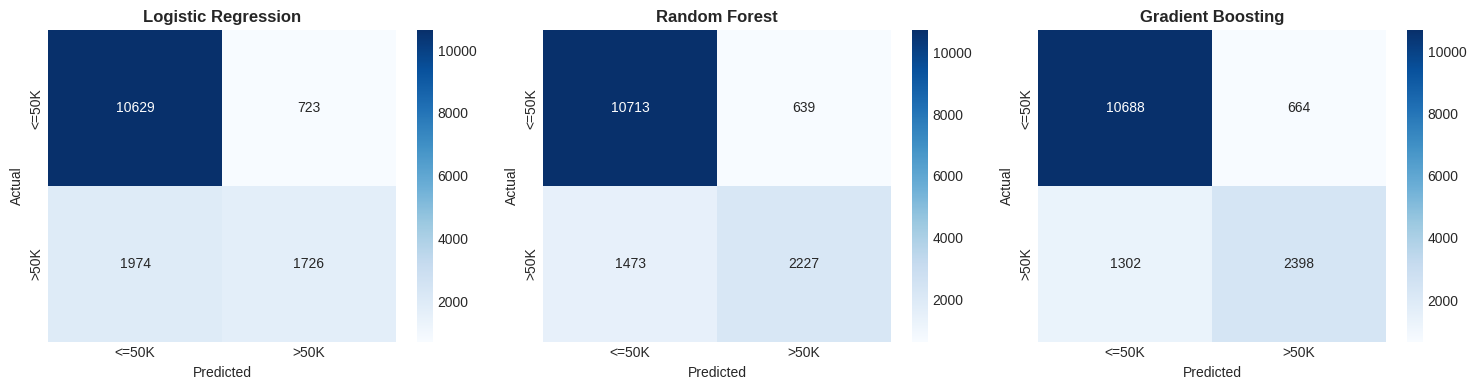

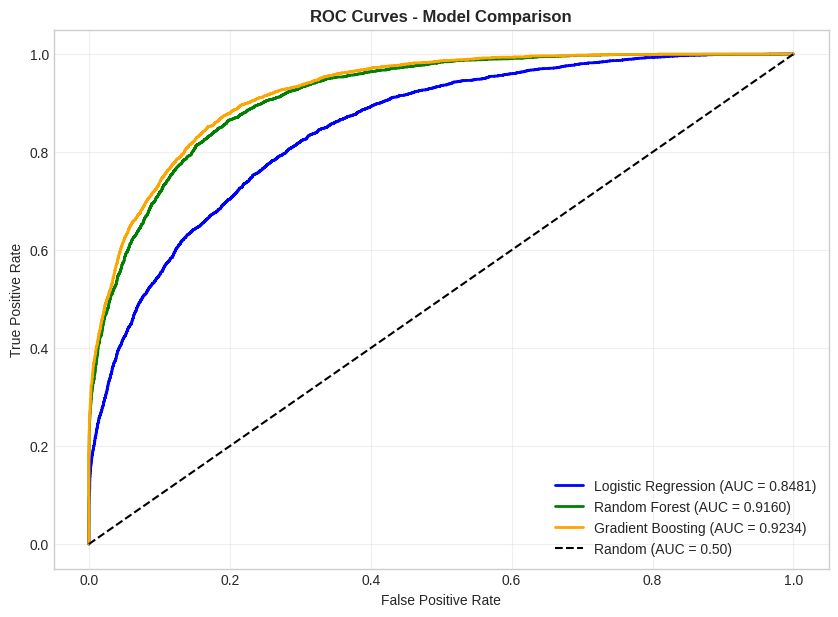


--- Classification Reports ---

Logistic Regression:
              precision    recall  f1-score   support

       <=50K       0.84      0.94      0.89     11352
        >50K       0.70      0.47      0.56      3700

    accuracy                           0.82     15052
   macro avg       0.77      0.70      0.72     15052
weighted avg       0.81      0.82      0.81     15052


Random Forest:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91     11352
        >50K       0.78      0.60      0.68      3700

    accuracy                           0.86     15052
   macro avg       0.83      0.77      0.79     15052
weighted avg       0.85      0.86      0.85     15052


Gradient Boosting:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92     11352
        >50K       0.78      0.65      0.71      3700

    accuracy                           0.87     15052
   macro avg       0.84      0.79     

In [9]:
# Final Model Evaluation on Test Set
print("FINAL EVALUATION ON TEST SET")

# Train final models on full training data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
y_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

# Performance metrics
def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

metrics_lr = get_metrics(y_test, y_pred_lr, y_proba_lr)
metrics_rf = get_metrics(y_test, y_pred_rf, y_proba_rf)
metrics_gb = get_metrics(y_test, y_pred_gb, y_proba_gb)

print("\nTest Set Results:")
test_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    'Logistic Regression': list(metrics_lr.values()),
    'Random Forest': list(metrics_rf.values()),
    'Gradient Boosting': list(metrics_gb.values())
})
print(test_results.to_string(index=False))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf), ('Gradient Boosting', y_pred_gb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(10, 7))
for name, y_proba, color in [('Logistic Regression', y_proba_lr, 'blue'), 
                              ('Random Forest', y_proba_rf, 'green'),
                              ('Gradient Boosting', y_proba_gb, 'orange')]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2, color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Classification Reports
print("\n--- Classification Reports ---")
for name, y_pred in [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf), ('Gradient Boosting', y_pred_gb)]:
    print(f"\n{name}:")
    print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# Part 3: Bias and Fairness Analysis 

In [10]:
# Bias and Fairness Analysis
print("BIAS AND FAIRNESS ANALYSIS")

# Fairness thresholds
DI_MIN, DI_MAX = 0.8, 1.25  # Disparate impact (4/5ths rule)
DP_THRESH = 0.1  # Demographic parity
EO_THRESH = 0.1  # Equal opportunity

def calculate_fairness_metrics(y_true, y_pred, protected_attr):
    """Calculate fairness metrics for each group"""
    results = {}
    for group in np.unique(protected_attr):
        mask = (protected_attr == group)
        y_t, y_p = y_true[mask], y_pred[mask]
        
        pos_rate = (y_p == 1).sum() / len(y_p)
        tp = ((y_t == 1) & (y_p == 1)).sum()
        fn = ((y_t == 1) & (y_p == 0)).sum()
        fp = ((y_t == 0) & (y_p == 1)).sum()
        tn = ((y_t == 0) & (y_p == 0)).sum()
        
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
        results[group] = {'pos_rate': pos_rate, 'tpr': tpr, 'fpr': fpr, 'total': len(y_p)}
    return results

y_test_arr = y_test.values
gender_test_arr = gender_test.values

# Fairness Metrics BEFORE SMOTE
print("\n--- Fairness Metrics BEFORE SMOTE ---")

print("\nLogistic Regression:")
fm_lr = calculate_fairness_metrics(y_test_arr, y_pred_lr, gender_test_arr)
for group, m in fm_lr.items():
    print(f"  {group}: Pos Rate={m['pos_rate']:.4f}, TPR={m['tpr']:.4f}, FPR={m['fpr']:.4f}")

di_lr = fm_lr['Female']['pos_rate'] / fm_lr['Male']['pos_rate']
dp_lr = abs(fm_lr['Female']['pos_rate'] - fm_lr['Male']['pos_rate'])
eo_lr = abs(fm_lr['Female']['tpr'] - fm_lr['Male']['tpr'])
eq_fpr_lr = abs(fm_lr['Female']['fpr'] - fm_lr['Male']['fpr'])

print(f"\n  Disparate Impact: {di_lr:.4f} (fair: {DI_MIN}-{DI_MAX}) - {'FAIR' if DI_MIN <= di_lr <= DI_MAX else 'UNFAIR'}")
print(f"  Demographic Parity: {dp_lr:.4f} (fair: <{DP_THRESH}) - {'FAIR' if dp_lr < DP_THRESH else 'UNFAIR'}")
print(f"  Equal Opportunity: {eo_lr:.4f} (fair: <{EO_THRESH}) - {'FAIR' if eo_lr < EO_THRESH else 'UNFAIR'}")
print(f"  Equalized Odds - TPR diff: {eo_lr:.4f}, FPR diff: {eq_fpr_lr:.4f}")

print("\nRandom Forest:")
fm_rf = calculate_fairness_metrics(y_test_arr, y_pred_rf, gender_test_arr)
for group, m in fm_rf.items():
    print(f"  {group}: Pos Rate={m['pos_rate']:.4f}, TPR={m['tpr']:.4f}, FPR={m['fpr']:.4f}")

di_rf = fm_rf['Female']['pos_rate'] / fm_rf['Male']['pos_rate']
dp_rf = abs(fm_rf['Female']['pos_rate'] - fm_rf['Male']['pos_rate'])
eo_rf = abs(fm_rf['Female']['tpr'] - fm_rf['Male']['tpr'])

print(f"\n  Disparate Impact: {di_rf:.4f} - {'FAIR' if DI_MIN <= di_rf <= DI_MAX else 'UNFAIR'}")
print(f"  Demographic Parity: {dp_rf:.4f} - {'FAIR' if dp_rf < DP_THRESH else 'UNFAIR'}")
print(f"  Equal Opportunity: {eo_rf:.4f} - {'FAIR' if eo_rf < EO_THRESH else 'UNFAIR'}")

print("\nGradient Boosting:")
fm_gb = calculate_fairness_metrics(y_test_arr, y_pred_gb, gender_test_arr)
for group, m in fm_gb.items():
    print(f"  {group}: Pos Rate={m['pos_rate']:.4f}, TPR={m['tpr']:.4f}, FPR={m['fpr']:.4f}")

di_gb = fm_gb['Female']['pos_rate'] / fm_gb['Male']['pos_rate']
dp_gb = abs(fm_gb['Female']['pos_rate'] - fm_gb['Male']['pos_rate'])
eo_gb = abs(fm_gb['Female']['tpr'] - fm_gb['Male']['tpr'])

print(f"\n  Disparate Impact: {di_gb:.4f} - {'FAIR' if DI_MIN <= di_gb <= DI_MAX else 'UNFAIR'}")
print(f"  Demographic Parity: {dp_gb:.4f} - {'FAIR' if dp_gb < DP_THRESH else 'UNFAIR'}")
print(f"  Equal Opportunity: {eo_gb:.4f} - {'FAIR' if eo_gb < EO_THRESH else 'UNFAIR'}")

BIAS AND FAIRNESS ANALYSIS

--- Fairness Metrics BEFORE SMOTE ---

Logistic Regression:
  Female: Pos Rate=0.0387, TPR=0.2118, FPR=0.0165
  Male: Pos Rate=0.2228, TPR=0.5116, FPR=0.0930

  Disparate Impact: 0.1736 (fair: 0.8-1.25) - UNFAIR
  Demographic Parity: 0.1841 (fair: <0.1) - UNFAIR
  Equal Opportunity: 0.2998 (fair: <0.1) - UNFAIR
  Equalized Odds - TPR diff: 0.2998, FPR diff: 0.0765

Random Forest:
  Female: Pos Rate=0.0798, TPR=0.5494, FPR=0.0197
  Male: Pos Rate=0.2440, TPR=0.6112, FPR=0.0790

  Disparate Impact: 0.3271 - UNFAIR
  Demographic Parity: 0.1642 - UNFAIR
  Equal Opportunity: 0.0618 - FAIR

Gradient Boosting:
  Female: Pos Rate=0.0853, TPR=0.5943, FPR=0.0202
  Male: Pos Rate=0.2607, TPR=0.6577, FPR=0.0823

  Disparate Impact: 0.3273 - UNFAIR
  Demographic Parity: 0.1753 - UNFAIR
  Equal Opportunity: 0.0634 - FAIR


## Apply SMOTE for Class Imbalance

APPLYING SMOTE FOR CLASS IMBALANCE

Before SMOTE:
  Class 0 (<=50K): 18104 (75.1%)
  Class 1 (>50K): 6005 (24.9%)

After SMOTE:
  Class 0 (<=50K): 18104 (50.0%)
  Class 1 (>50K): 18104 (50.0%)
  Synthetic samples created: 12099


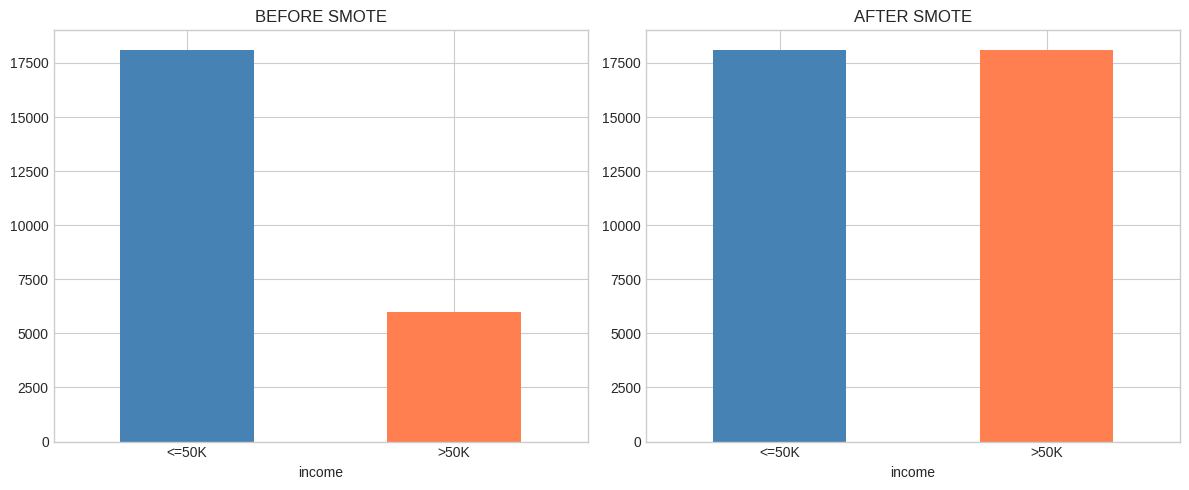

In [11]:
# Apply SMOTE for Class Imbalance
print("APPLYING SMOTE FOR CLASS IMBALANCE")

print(f"\nBefore SMOTE:")
print(f"  Class 0 (<=50K): {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"  Class 1 (>50K): {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Class 0 (<=50K): {(y_train_smote==0).sum()} ({(y_train_smote==0).sum()/len(y_train_smote)*100:.1f}%)")
print(f"  Class 1 (>50K): {(y_train_smote==1).sum()} ({(y_train_smote==1).sum()/len(y_train_smote)*100:.1f}%)")
print(f"  Synthetic samples created: {len(y_train_smote) - len(y_train)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('BEFORE SMOTE')
axes[0].set_xticklabels(['<=50K', '>50K'], rotation=0)

pd.Series(y_train_smote).value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('AFTER SMOTE')
axes[1].set_xticklabels(['<=50K', '>50K'], rotation=0)
plt.tight_layout()
plt.show()

## Retrain models with SMOTE data

In [12]:
# Retrain models with SMOTE data
print("\n--- Retraining Models with SMOTE ---")

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
y_proba_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

rf_smote = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test_scaled)
y_proba_rf_smote = rf_smote.predict_proba(X_test_scaled)[:, 1]

gb_smote = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_smote.fit(X_train_smote, y_train_smote)
y_pred_gb_smote = gb_smote.predict(X_test_scaled)
y_proba_gb_smote = gb_smote.predict_proba(X_test_scaled)[:, 1]

# Performance after SMOTE
print("\nPerformance After SMOTE:")

m_lr_s = get_metrics(y_test, y_pred_lr_smote, y_proba_lr_smote)
m_rf_s = get_metrics(y_test, y_pred_rf_smote, y_proba_rf_smote)
m_gb_s = get_metrics(y_test, y_pred_gb_smote, y_proba_gb_smote)

print(f"\nLogistic Regression: Acc={m_lr_s['Accuracy']:.4f}, F1={m_lr_s['F1']:.4f}, AUC={m_lr_s['ROC-AUC']:.4f}")
print(f"  (Before: Acc={metrics_lr['Accuracy']:.4f}, F1={metrics_lr['F1']:.4f}, AUC={metrics_lr['ROC-AUC']:.4f})")

print(f"\nRandom Forest: Acc={m_rf_s['Accuracy']:.4f}, F1={m_rf_s['F1']:.4f}, AUC={m_rf_s['ROC-AUC']:.4f}")
print(f"  (Before: Acc={metrics_rf['Accuracy']:.4f}, F1={metrics_rf['F1']:.4f}, AUC={metrics_rf['ROC-AUC']:.4f})")

print(f"\nGradient Boosting: Acc={m_gb_s['Accuracy']:.4f}, F1={m_gb_s['F1']:.4f}, AUC={m_gb_s['ROC-AUC']:.4f}")
print(f"  (Before: Acc={metrics_gb['Accuracy']:.4f}, F1={metrics_gb['F1']:.4f}, AUC={metrics_gb['ROC-AUC']:.4f})")


--- Retraining Models with SMOTE ---

Performance After SMOTE:

Logistic Regression: Acc=0.7574, F1=0.6032, AUC=0.8474
  (Before: Acc=0.8208, F1=0.5614, AUC=0.8481)

Random Forest: Acc=0.8335, F1=0.7023, AUC=0.9134
  (Before: Acc=0.8597, F1=0.6783, AUC=0.9160)

Gradient Boosting: Acc=0.8504, F1=0.7202, AUC=0.9199
  (Before: Acc=0.8694, F1=0.7093, AUC=0.9234)


## Fairness Metrics After SMOTE

In [13]:
# Fairness Metrics AFTER SMOTE
print("\n--- Fairness Metrics AFTER SMOTE ---")

print("\nLogistic Regression (After SMOTE):")
fm_lr_s = calculate_fairness_metrics(y_test_arr, y_pred_lr_smote, gender_test_arr)
for group, m in fm_lr_s.items():
    print(f"  {group}: Pos Rate={m['pos_rate']:.4f}, TPR={m['tpr']:.4f}, FPR={m['fpr']:.4f}")

di_lr_s = fm_lr_s['Female']['pos_rate'] / fm_lr_s['Male']['pos_rate']
dp_lr_s = abs(fm_lr_s['Female']['pos_rate'] - fm_lr_s['Male']['pos_rate'])
eo_lr_s = abs(fm_lr_s['Female']['tpr'] - fm_lr_s['Male']['tpr'])

print(f"\n  Disparate Impact: {di_lr_s:.4f} (was {di_lr:.4f})")
print(f"  Demographic Parity: {dp_lr_s:.4f} (was {dp_lr:.4f})")
print(f"  Equal Opportunity: {eo_lr_s:.4f} (was {eo_lr:.4f})")

print("\nRandom Forest (After SMOTE):")
fm_rf_s = calculate_fairness_metrics(y_test_arr, y_pred_rf_smote, gender_test_arr)
for group, m in fm_rf_s.items():
    print(f"  {group}: Pos Rate={m['pos_rate']:.4f}, TPR={m['tpr']:.4f}, FPR={m['fpr']:.4f}")

di_rf_s = fm_rf_s['Female']['pos_rate'] / fm_rf_s['Male']['pos_rate']
dp_rf_s = abs(fm_rf_s['Female']['pos_rate'] - fm_rf_s['Male']['pos_rate'])
eo_rf_s = abs(fm_rf_s['Female']['tpr'] - fm_rf_s['Male']['tpr'])

print(f"\n  Disparate Impact: {di_rf_s:.4f} (was {di_rf:.4f})")
print(f"  Demographic Parity: {dp_rf_s:.4f} (was {dp_rf:.4f})")
print(f"  Equal Opportunity: {eo_rf_s:.4f} (was {eo_rf:.4f})")

print("\nGradient Boosting (After SMOTE):")
fm_gb_s = calculate_fairness_metrics(y_test_arr, y_pred_gb_smote, gender_test_arr)
for group, m in fm_gb_s.items():
    print(f"  {group}: Pos Rate={m['pos_rate']:.4f}, TPR={m['tpr']:.4f}, FPR={m['fpr']:.4f}")

di_gb_s = fm_gb_s['Female']['pos_rate'] / fm_gb_s['Male']['pos_rate']
dp_gb_s = abs(fm_gb_s['Female']['pos_rate'] - fm_gb_s['Male']['pos_rate'])
eo_gb_s = abs(fm_gb_s['Female']['tpr'] - fm_gb_s['Male']['tpr'])

print(f"\n  Disparate Impact: {di_gb_s:.4f} (was {di_gb:.4f})")
print(f"  Demographic Parity: {dp_gb_s:.4f} (was {dp_gb:.4f})")
print(f"  Equal Opportunity: {eo_gb_s:.4f} (was {eo_gb:.4f})")



--- Fairness Metrics AFTER SMOTE ---

Logistic Regression (After SMOTE):
  Female: Pos Rate=0.1348, TPR=0.4399, FPR=0.0958
  Male: Pos Rate=0.4772, TPR=0.8050, FPR=0.3300

  Disparate Impact: 0.2824 (was 0.1736)
  Demographic Parity: 0.3424 (was 0.1841)
  Equal Opportunity: 0.3651 (was 0.2998)

Random Forest (After SMOTE):
  Female: Pos Rate=0.1124, TPR=0.6553, FPR=0.0429
  Male: Pos Rate=0.4108, TPR=0.8244, FPR=0.2251

  Disparate Impact: 0.2735 (was 0.3271)
  Demographic Parity: 0.2985 (was 0.1642)
  Equal Opportunity: 0.1691 (was 0.0618)

Gradient Boosting (After SMOTE):
  Female: Pos Rate=0.1087, TPR=0.6732, FPR=0.0365
  Male: Pos Rate=0.3761, TPR=0.8027, FPR=0.1845

  Disparate Impact: 0.2890 (was 0.3273)
  Demographic Parity: 0.2674 (was 0.1753)
  Equal Opportunity: 0.1295 (was 0.0634)


## Comparison Visualization


--- Before vs After SMOTE Comparison ---


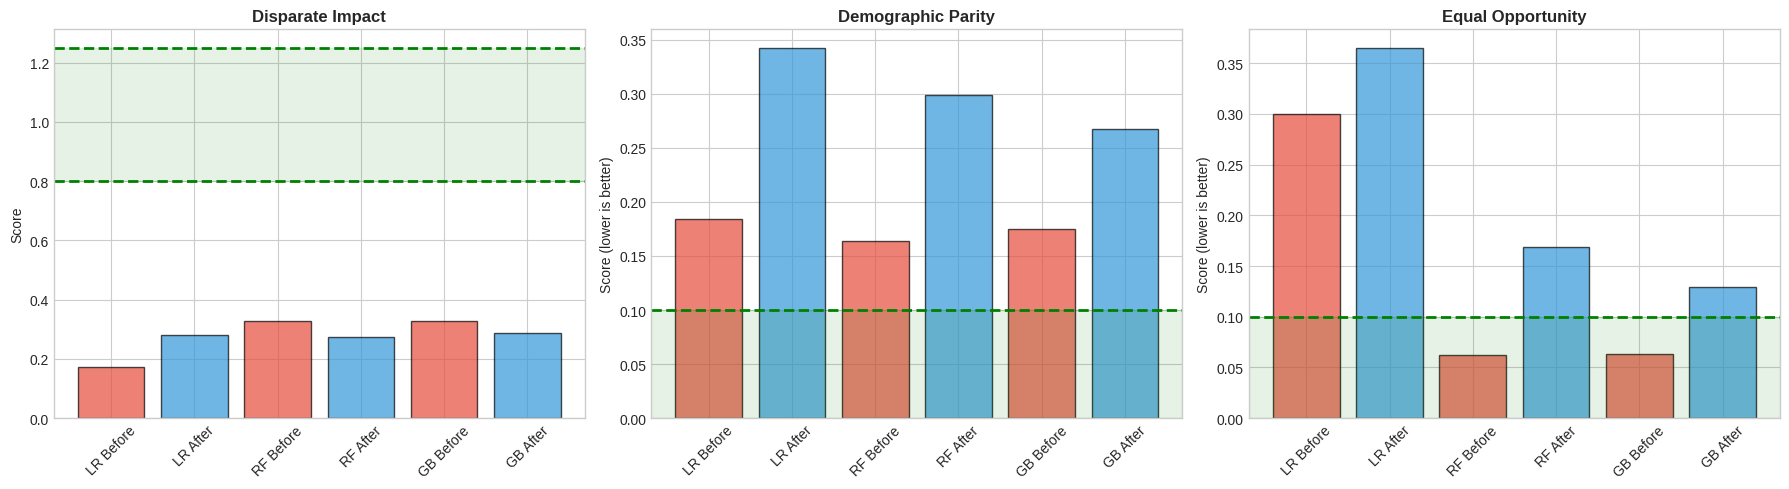


--- Fairness Summary Table ---
         Model  Disparate Impact  Demographic Parity  Equal Opportunity
     LR Before          0.173627            0.184100           0.299764
LR After SMOTE          0.282411            0.342447           0.365107
     RF Before          0.327089            0.164180           0.061828
RF After SMOTE          0.273527            0.298470           0.169075
     GB Before          0.327263            0.175350           0.063397
GB After SMOTE          0.289028            0.267421           0.129487

Key Finding:
SMOTE addresses CLASS imbalance (<=50K vs >50K) but does NOT automatically
fix DEMOGRAPHIC bias (Male vs Female). These are different problems!


In [14]:
# Comparison Visualization
print("\n--- Before vs After SMOTE Comparison ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = ['LR Before', 'LR After', 'RF Before', 'RF After', 'GB Before', 'GB After']
colors = ['#e74c3c', '#3498db', '#e74c3c', '#3498db', '#e74c3c', '#3498db']

# Disparate Impact
di_vals = [di_lr, di_lr_s, di_rf, di_rf_s, di_gb, di_gb_s]
axes[0].bar(x, di_vals, color=colors, alpha=0.7, edgecolor='black')
axes[0].axhline(y=0.8, color='green', linestyle='--', linewidth=2)
axes[0].axhline(y=1.25, color='green', linestyle='--', linewidth=2)
axes[0].axhspan(0.8, 1.25, alpha=0.1, color='green')
axes[0].set_title('Disparate Impact', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

# Demographic Parity
dp_vals = [dp_lr, dp_lr_s, dp_rf, dp_rf_s, dp_gb, dp_gb_s]
axes[1].bar(x, dp_vals, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0.1, color='green', linestyle='--', linewidth=2)
axes[1].axhspan(0, 0.1, alpha=0.1, color='green')
axes[1].set_title('Demographic Parity', fontweight='bold')
axes[1].set_ylabel('Score (lower is better)')
axes[1].tick_params(axis='x', rotation=45)

# Equal Opportunity
eo_vals = [eo_lr, eo_lr_s, eo_rf, eo_rf_s, eo_gb, eo_gb_s]
axes[2].bar(x, eo_vals, color=colors, alpha=0.7, edgecolor='black')
axes[2].axhline(y=0.1, color='green', linestyle='--', linewidth=2)
axes[2].axhspan(0, 0.1, alpha=0.1, color='green')
axes[2].set_title('Equal Opportunity', fontweight='bold')
axes[2].set_ylabel('Score (lower is better)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary table
print("\n--- Fairness Summary Table ---")
fairness_summary = pd.DataFrame({
    'Model': ['LR Before', 'LR After SMOTE', 'RF Before', 'RF After SMOTE', 'GB Before', 'GB After SMOTE'],
    'Disparate Impact': [di_lr, di_lr_s, di_rf, di_rf_s, di_gb, di_gb_s],
    'Demographic Parity': [dp_lr, dp_lr_s, dp_rf, dp_rf_s, dp_gb, dp_gb_s],
    'Equal Opportunity': [eo_lr, eo_lr_s, eo_rf, eo_rf_s, eo_gb, eo_gb_s]
})
print(fairness_summary.to_string(index=False))

print("\nKey Finding:")
print("SMOTE addresses CLASS imbalance (<=50K vs >50K) but does NOT automatically")
print("fix DEMOGRAPHIC bias (Male vs Female). These are different problems!")

# Final Summary

In [15]:
# Final Summary
print("FINAL SUMMARY")

print("""
PART 1: Exploratory Data Analysis & Statistical Testing
- Data cleaned (missing values removed, duplicates dropped)
- Class imbalance identified (~75% <=50K, ~25% >50K)
- All statistical tests performed:
  * Shapiro-Wilk (normality) - most variables NOT normal
  * Levene's (variance) - unequal variances in some variables  
  * T-Tests (group means) - significant differences found
  * Mann-Whitney U (non-parametric) - confirms t-test results
  * Chi-Square (categorical) - gender, race, education all associated with income
  * Pearson & Spearman correlations computed

PART 2: Machine Learning
- Three models trained: Logistic Regression, Random Forest, Gradient Boosting
- 30 repeated cross-validation runs for reliable estimates
- Statistical comparison using Wilcoxon signed-rank test
- All required metrics computed: accuracy, precision, recall, F1, ROC-AUC

PART 3: Bias and Fairness Analysis
- Fairness metrics calculated for Gender attribute:
  * Disparate Impact (4/5ths rule)
  * Demographic Parity
  * Equal Opportunity
  * Equalized Odds (TPR and FPR)
- Before/After SMOTE comparison shows:
  * SMOTE improves recall (better at finding high earners)
  * SMOTE does NOT automatically fix demographic bias
  * Class imbalance ≠ demographic bias
""")

FINAL SUMMARY

PART 1: Exploratory Data Analysis & Statistical Testing
- Data cleaned (missing values removed, duplicates dropped)
- Class imbalance identified (~75% <=50K, ~25% >50K)
- All statistical tests performed:
  * Shapiro-Wilk (normality) - most variables NOT normal
  * Levene's (variance) - unequal variances in some variables  
  * T-Tests (group means) - significant differences found
  * Mann-Whitney U (non-parametric) - confirms t-test results
  * Chi-Square (categorical) - gender, race, education all associated with income
  * Pearson & Spearman correlations computed

PART 2: Machine Learning
- Three models trained: Logistic Regression, Random Forest, Gradient Boosting
- 30 repeated cross-validation runs for reliable estimates
- Statistical comparison using Wilcoxon signed-rank test
- All required metrics computed: accuracy, precision, recall, F1, ROC-AUC

PART 3: Bias and Fairness Analysis
- Fairness metrics calculated for Gender attribute:
  * Disparate Impact (4/5ths ru